In [ ]:
# ============================================================
# MAPCT-v9: HYBRID NORMALIZING FLOW + LATENT DIFFUSION
# With Structured & Semantic Mechanism Awareness
# ============================================================
!pip install umap-learn

import os
import re
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from typing import Dict, List, Tuple, Optional


import seaborn as sns

from sklearn.metrics import roc_curve, auc, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Normal

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False




Using device: cpu


In [ ]:
# ============================================================
# SECTION 0: DRUG NAME SORTING & NORMALIZATION
# ============================================================

def normalize_drug_name(name: str) -> str:
    """Normalize drug name by removing brand info and standardizing format"""
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)  # Remove (brand: xxx)
    name = re.sub(r"\s+brand:.*", "", name, flags=re.IGNORECASE)
    name = re.sub(r"\s*\+\s*", ", ", name)  # Standardize plus to comma
    name = re.sub(r"\s*,\s*", ", ", name)   # Standardize commas
    name = re.sub(r"\s+", " ", name)        # Collapse multiple spaces
    return name.strip()


def sort_drug_combo(combo: str) -> str:
    """Sort drugs within a combination alphabetically"""
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    drugs = sorted(drugs)  # Alphabetical sorting
    return ", ".join(drugs)


def split_combo(combo: str) -> List[str]:
    """Split a combo string into individual drug names"""
    if not isinstance(combo, str):
        return []
    return [d.strip() for d in combo.split(",") if d.strip()]


def deduplicate_combo(combo: str) -> str:
    """Remove duplicate drugs within a combination"""
    drugs = split_combo(combo)
    unique_drugs = sorted(set(drugs))
    return ", ".join(unique_drugs)




In [ ]:
# ============================================================
# SECTION 1: DATA LOADING
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1, engine="openpyxl")
mech_df = pd.read_excel(file_path2, engine="openpyxl")

print(f"Loaded {len(clinic_df)} patients, {len(mech_df)} mechanism entries")

# ===== STEP 1: Create the normalized and sorted column =====
print("\n" + "="*70)
print("🔧 PREPROCESSING AND SORTING DRUG NAMES")
print("="*70)

# Apply normalization and sorting to create merged_drugs_norm
clinic_df["merged_drugs_norm"] = (
    clinic_df["merged_drugs"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
    .apply(deduplicate_combo)
)

# Also normalize mechanism table
mech_df["Drug Name Norm"] = (
    mech_df["Drug Name"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
    .apply(deduplicate_combo)
)

print(f"✅ Created 'merged_drugs_norm' column")
print(f"   Unique regimens after sorting: {clinic_df['merged_drugs_norm'].nunique()}")
print(f"   Sample: {clinic_df['merged_drugs_norm'].iloc[0]}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 4547 patients, 164 mechanism entries

🔧 PREPROCESSING AND SORTING DRUG NAMES
✅ Created 'merged_drugs_norm' column
   Unique regimens after sorting: 1365
   Sample: aspirin, atorvastatin, gliclazide, metformin


In [ ]:
# ============================================================
# SECTION 2: LEAK-PROOF TRAIN/VAL/TEST SPLIT
# ============================================================

# ============================================================
# SECTION 2: LEAKAGE‑FREE SPLIT BY REGIMEN (GROUP‑BASED)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

# Define columns (keep as is)
numeric_cols = ["fbs", "glu", "hba1c", "TG", "cho", "LDL", "HDL", "UA", "Na", "K", "Ca", "Vit D", "age"]
categorical_cols = ["sex", "fbs_category", "tg_category", "cho_category"]

# Drop rows with missing values
clinic_df = clinic_df.dropna(subset=numeric_cols + categorical_cols).reset_index(drop=True)

# Groups = unique drug combination strings
groups = clinic_df["merged_drugs_norm"]

# First split: test set (20% of groups)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_val, idx_test = next(gss1.split(clinic_df, groups=groups))

# Second split: validation set (20% of remaining groups → 16% of patients)
groups_train_val = groups.iloc[idx_train_val]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss2.split(clinic_df.iloc[idx_train_val], groups=groups_train_val))

# Convert indices
idx_train = idx_train_val[idx_train_rel]
idx_val = idx_train_val[idx_val_rel]
# idx_test remains as is

# Create dataframes
train_df = clinic_df.iloc[idx_train].copy()
val_df = clinic_df.iloc[idx_val].copy()
test_df = clinic_df.iloc[idx_test].copy()

print(f"Leakage‑free splits: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Sanity check: no drug combination appears in both train and test
train_combos = set(clinic_df.iloc[idx_train]["merged_drugs_norm"])
test_combos  = set(clinic_df.iloc[idx_test]["merged_drugs_norm"])
assert len(train_combos & test_combos) == 0, "❌ Leakage detected!"
print("✅ Verified: train and test have no common regimens.")


# ============================================================
# SECTION 3: DRUG VOCABULARY (TRAIN ONLY)
# ============================================================

def build_drug_vocabulary(train_df):
    """Build drug vocabulary from training data ONLY"""
    all_drugs = set()
    for combo in train_df["merged_drugs_norm"]:
        for drug in split_combo(combo):
            all_drugs.add(drug)
    drug_to_idx = {drug: i for i, drug in enumerate(sorted(all_drugs))}
    idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
    return drug_to_idx, idx_to_drug, len(drug_to_idx)

def encode_regimen_multi_hot(combo, drug_to_idx):
    """Convert regimen to multi-hot vector"""
    vec = np.zeros(len(drug_to_idx), dtype=np.float32)
    for drug in split_combo(combo):
        if drug in drug_to_idx:
            vec[drug_to_idx[drug]] = 1.0
    return vec

def filter_to_train_vocab(combo, drug_to_idx):
    """Filter out drugs not in training vocabulary"""
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    filtered = [d for d in drugs if d in drug_to_idx]
    return ", ".join(sorted(filtered))

# Build vocabulary from train only
drug_to_idx, idx_to_drug, num_drugs = build_drug_vocabulary(train_df)
drug_vocab = list(drug_to_idx.keys())
print(f"Drug vocabulary size: {num_drugs}")

# Filter val/test to train vocabulary
val_df["merged_drugs_norm"] = val_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))
test_df["merged_drugs_norm"] = test_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))


# ============================================================
# SECTION 4: CLINICAL PREPROCESSING
# ============================================================

scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_num_train = scaler.fit_transform(train_df[numeric_cols])
X_cat_train = ohe.fit_transform(train_df[categorical_cols])
X_train = np.hstack([X_num_train, X_cat_train])

X_num_val = scaler.transform(val_df[numeric_cols])
X_cat_val = ohe.transform(val_df[categorical_cols])
X_val = np.hstack([X_num_val, X_cat_val])

X_num_test = scaler.transform(test_df[numeric_cols])
X_cat_test = ohe.transform(test_df[categorical_cols])
X_test = np.hstack([X_num_test, X_cat_test])

print(f"Clinical feature dimension: {X_train.shape[1]}")



Splits: Train=3182, Val=455, Test=910
Drug vocabulary size: 160
Clinical feature dimension: 25


In [ ]:
# ============================================================
# SECTION 5: MECHANISM EMBEDDINGS (FIXED DIMENSION)
# ============================================================

from sentence_transformers import SentenceTransformer

def build_mechanism_embeddings(train_drugs, mech_df, embed_dim=128):
    """Build real mechanism embeddings with consistent dimension"""
    print("\n" + "="*70)
    print("🔬 BUILDING REAL MECHANISM EMBEDDINGS")
    print("="*70)

    # Load sentence transformer model
    model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    actual_embed_dim = model.get_embedding_dimension()   # fixed method name
    print(f"   Raw model dimension: {actual_embed_dim}")
    print(f"   Target dimension: {embed_dim}")

    # Create projection layer if needed (disable gradients)
    if actual_embed_dim != embed_dim:
        projection = nn.Linear(actual_embed_dim, embed_dim, bias=False).to(device)
        projection.requires_grad_(False)   # not trainable
        print(f"   ✅ Created projection layer: {actual_embed_dim} → {embed_dim}")
    else:
        projection = None

    embeddings = {}
    missing_drugs = []

    for drug in tqdm(train_drugs, desc="Building mechanism embeddings"):
        # Get mechanism text for drug
        row = mech_df[mech_df["Drug Name Norm"] == drug]

        if len(row) > 0:
            # Build text from available fields
            text_cols = ["Mechanisms", "Description", "Target IDs", "Pathway IDs", "ATC Code(s)"]
            text_parts = []
            for col in text_cols:
                if col in row.columns and pd.notna(row.iloc[0].get(col)):
                    text_parts.append(str(row.iloc[0][col]))

            if text_parts:
                text = " | ".join(text_parts)
            else:
                text = drug  # Fallback to drug name

            # Generate embedding (inference mode tensor)
            emb = model.encode(text, convert_to_tensor=True)

            # Project to target dimension without tracking gradients
            if projection is not None:
                with torch.no_grad():
                    # shape: (1, actual_dim) -> (1, embed_dim) -> squeeze to (embed_dim,)
                    emb = projection(emb.unsqueeze(0)).squeeze(0).cpu()
            else:
                emb = emb.cpu()

            # Normalize and store
            embeddings[drug] = F.normalize(emb, dim=0)
        else:
            # No mechanism data - zero embedding of correct size
            embeddings[drug] = torch.zeros(embed_dim)
            missing_drugs.append(drug)

    if missing_drugs:
        print(f"   ⚠️ No mechanism data for {len(missing_drugs)} drugs (using zero embeddings)")
        if len(missing_drugs) <= 10:
            print(f"      Missing: {missing_drugs}")

    print(f"✅ Built real embeddings for {len(embeddings)} drugs (dim={embed_dim})")
    return embeddings, embed_dim


# ===== NOW ACTUALLY BUILD THE EMBEDDINGS =====
train_drugs_set = set(drug_to_idx.keys())
drug_embeddings, embed_dim = build_mechanism_embeddings(train_drugs_set, mech_df, embed_dim=128)
print(f"✅ Global drug_embeddings created with {len(drug_embeddings)} drugs of dimension {embed_dim}")


🔬 BUILDING REAL MECHANISM EMBEDDINGS


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Raw model dimension: 384
   Target dimension: 128
   ✅ Created projection layer: 384 → 128


Building mechanism embeddings: 100%|██████████| 160/160 [00:04<00:00, 32.68it/s]

   ⚠️ No mechanism data for 55 drugs (using zero embeddings)
✅ Built real embeddings for 160 drugs (dim=128)
✅ Global drug_embeddings created with 160 drugs of dimension 128


In [ ]:
# ============================================================
# SECTION 6: REGIMEN MECHANISM TENSOR (FIXED)
# ============================================================

MAX_DRUGS = 10

# Build drug embeddings FIRST (this should already be done in SECTION 5)
# Make sure drug_embeddings exists
if 'drug_embeddings' not in globals():
    print("❌ drug_embeddings not found! Run SECTION 5 first.")
else:
    # Get the actual embedding dimension from drug_embeddings
    sample_emb = next(iter(drug_embeddings.values())) if drug_embeddings else None
    if sample_emb is not None:
        ACTUAL_EMBED_DIM = sample_emb.shape[0]
    else:
        ACTUAL_EMBED_DIM = 128

    print(f"Actual embedding dimension from drug_embeddings: {ACTUAL_EMBED_DIM}")

def build_regimen_mechanism_tensor(combo, drug_embeddings, max_drugs=MAX_DRUGS, embed_dim=None):
    """Build mechanism tensor for a regimen (stacked drug embeddings)"""
    if embed_dim is None:
        # Get dimension from first embedding
        sample_emb = next(iter(drug_embeddings.values())) if drug_embeddings else None
        embed_dim = sample_emb.shape[0] if sample_emb is not None else 128

    drugs = split_combo(combo)[:max_drugs]
    tensor = torch.zeros(max_drugs, embed_dim)
    for i, drug in enumerate(drugs):
        emb = drug_embeddings.get(drug, torch.zeros(embed_dim))
        # Ensure emb has correct dimension
        if emb.shape[0] != embed_dim:
            # Simple truncation/padding
            if emb.shape[0] > embed_dim:
                emb = emb[:embed_dim]
            else:
                # Pad with zeros
                padding = torch.zeros(embed_dim - emb.shape[0])
                emb = torch.cat([emb, padding])
        tensor[i] = emb
    mask = torch.zeros(max_drugs, dtype=torch.bool)
    mask[:len(drugs)] = True
    return tensor, mask




Actual embedding dimension from drug_embeddings: 128


In [ ]:
# ============================================================
# SECTION 7: DATASET CLASS AND DATALOADERS (REORDERED)
# ============================================================

# Define RegimenDataset FIRST
class RegimenDataset(Dataset):
    def __init__(self, df, clinical_features, drug_to_idx, drug_embeddings, embed_dim=None):
        self.df = df.reset_index(drop=True)
        self.clinical_features = clinical_features
        self.drug_to_idx = drug_to_idx
        self.drug_embeddings = drug_embeddings

        # Get actual embedding dimension
        if embed_dim is None:
            sample_emb = next(iter(drug_embeddings.values())) if drug_embeddings else None
            self.embed_dim = sample_emb.shape[0] if sample_emb is not None else 128
        else:
            self.embed_dim = embed_dim

        self.num_drugs = len(drug_to_idx)
        print(f"RegimenDataset using embed_dim={self.embed_dim}")

        # Precompute labels
        self.labels = []
        for _, row in self.df.iterrows():
            label = encode_regimen_multi_hot(row["merged_drugs_norm"], drug_to_idx)
            self.labels.append(label)

        # Precompute mechanism tensors
        self.mech_tensors = []
        self.mech_masks = []
        for _, row in self.df.iterrows():
            tensor, mask = build_regimen_mechanism_tensor(
                row["merged_drugs_norm"], drug_embeddings,
                embed_dim=self.embed_dim
            )
            self.mech_tensors.append(tensor)
            self.mech_masks.append(mask)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            'clinical': torch.tensor(self.clinical_features[idx], dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32),
            'mech_tensor': self.mech_tensors[idx],
            'mech_mask': self.mech_masks[idx]
        }


# ============================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================

print("\n" + "="*70)
print("📦 CREATING DATASETS AND DATALOADERS")
print("="*70)

# Ensure X_train, X_val, X_test are numpy arrays (not tensors)
if isinstance(X_train, torch.Tensor):
    X_train_np = X_train.cpu().numpy()
else:
    X_train_np = X_train

if isinstance(X_val, torch.Tensor):
    X_val_np = X_val.cpu().numpy()
else:
    X_val_np = X_val

if isinstance(X_test, torch.Tensor):
    X_test_np = X_test.cpu().numpy()
else:
    X_test_np = X_test

# Get actual embedding dimension
ACTUAL_EMBED_DIM = list(drug_embeddings.values())[0].shape[0] if drug_embeddings else 128
print(f"Actual drug embedding dimension: {ACTUAL_EMBED_DIM}")

# Create datasets
train_dataset = RegimenDataset(train_df, X_train_np, drug_to_idx, drug_embeddings, embed_dim=ACTUAL_EMBED_DIM)
val_dataset = RegimenDataset(val_df, X_val_np, drug_to_idx, drug_embeddings, embed_dim=ACTUAL_EMBED_DIM)
test_dataset = RegimenDataset(test_df, X_test_np, drug_to_idx, drug_embeddings, embed_dim=ACTUAL_EMBED_DIM)

# Create dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ train_loader: {len(train_loader)} batches")
print(f"✅ val_loader: {len(val_loader)} batches")
print(f"✅ test_loader: {len(test_loader)} batches")

# Verify everything works
print("\n" + "="*70)
print("🔍 VERIFYING DATALOADERS")
print("="*70)

sample_batch = next(iter(train_loader))
print(f"Sample batch - clinical shape: {sample_batch['clinical'].shape}")
print(f"Sample batch - label shape: {sample_batch['label'].shape}")
print(f"Sample batch - mech_tensor shape: {sample_batch['mech_tensor'].shape}")
print(f"Sample batch - mech_mask shape: {sample_batch['mech_mask'].shape}")
print("✅ Dataloaders working correctly!")



📦 CREATING DATASETS AND DATALOADERS
Actual drug embedding dimension: 128
RegimenDataset using embed_dim=128
RegimenDataset using embed_dim=128
RegimenDataset using embed_dim=128
✅ train_loader: 100 batches
✅ val_loader: 15 batches
✅ test_loader: 29 batches

🔍 VERIFYING DATALOADERS
Sample batch - clinical shape: torch.Size([32, 25])
Sample batch - label shape: torch.Size([32, 160])
Sample batch - mech_tensor shape: torch.Size([32, 10, 128])
Sample batch - mech_mask shape: torch.Size([32, 10])
✅ Dataloaders working correctly!


In [ ]:
# ============================================================
# SECTION 8: SIMPLE MODEL FOR TESTING
# ============================================================

class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)


class RegimenMechanismEncoder(nn.Module):
    def __init__(self, embed_dim=None, latent_dim=128, n_heads=4, n_layers=2):
        super().__init__()
        # Use ACTUAL_EMBED_DIM from global scope
        if embed_dim is None:
            embed_dim = ACTUAL_EMBED_DIM
        self.input_proj = nn.Linear(embed_dim, latent_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim, nhead=n_heads, batch_first=True, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.pool_proj = nn.Linear(latent_dim, latent_dim)

    def forward(self, mech_tensor, mask):
        x = self.input_proj(mech_tensor)
        x = self.transformer(x, src_key_padding_mask=~mask)
        mask_expanded = mask.unsqueeze(-1).float()
        pooled = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        return F.normalize(self.pool_proj(pooled), dim=1)

class DrugDecoder(nn.Module):
    def __init__(self, latent_dim=128, num_drugs=None, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_drugs)
        )

    def forward(self, z):
        return self.net(z)


class MAPCTv9Simple(nn.Module):
    def __init__(self, clin_dim, num_drugs, latent_dim=128, embed_dim=ACTUAL_EMBED_DIM):
        super().__init__()
        self.clinical_encoder = ClinicalEncoder(clin_dim, latent_dim)
        self.regimen_encoder = RegimenMechanismEncoder(embed_dim=embed_dim, latent_dim=latent_dim)
        self.drug_decoder = DrugDecoder(latent_dim=latent_dim, num_drugs=num_drugs)

    def forward(self, clinical, mech_tensor, mech_mask):
        z_clin = self.clinical_encoder(clinical)
        z_reg = self.regimen_encoder(mech_tensor, mech_mask)
        logits = self.drug_decoder(z_clin)
        return logits, z_clin, z_reg




In [ ]:
# ============================================================
# SECTION 9: TRAINER
# ============================================================

def contrastive_loss(z1, z2, temperature=0.07):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_fwd = F.cross_entropy(logits, labels)
    loss_rev = F.cross_entropy(logits.T, labels)
    return (loss_fwd + loss_rev) / 2

class Trainer:
    def __init__(self, model, device, drug_vocab, drug_to_idx):
        self.model = model.to(device)
        self.device = device
        self.drug_vocab = drug_vocab
        self.drug_to_idx = drug_to_idx
        self.idx_to_drug = {v: k for k, v in drug_to_idx.items()}  # Add this line

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=1e-3, weight_decay=1e-5)
        self.alpha_contrast = 0.3
        self.beta_drug = 1.0

        # For tracking losses
        self.train_losses = []
        self.val_losses = []

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0

        for batch in tqdm(train_loader, desc="Training"):
            clinical = batch['clinical'].to(self.device)
            labels = batch['label'].to(self.device)
            mech_tensor = batch['mech_tensor'].to(self.device)
            mech_mask = batch['mech_mask'].to(self.device)

            logits, z_clin, z_reg = self.model(clinical, mech_tensor, mech_mask)

            loss_drug = F.binary_cross_entropy_with_logits(logits, labels)
            loss_contrast = contrastive_loss(z_clin, z_reg)
            loss = self.beta_drug * loss_drug + self.alpha_contrast * loss_contrast

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return {'loss': total_loss / len(train_loader)}

    def train(self, train_loader, val_loader, epochs=10):
        for epoch in range(epochs):
            train_metrics = self.train_epoch(train_loader)
            self.train_losses.append(train_metrics['loss'])

            # Validation
            self.model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch in val_loader:
                    clinical = batch['clinical'].to(self.device)
                    labels = batch['label'].to(self.device)
                    mech_tensor = batch['mech_tensor'].to(self.device)
                    mech_mask = batch['mech_mask'].to(self.device)

                    logits, z_clin, z_reg = self.model(clinical, mech_tensor, mech_mask)
                    loss_drug = F.binary_cross_entropy_with_logits(logits, labels)
                    loss_contrast = contrastive_loss(z_clin, z_reg)
                    val_loss += (self.beta_drug * loss_drug + self.alpha_contrast * loss_contrast).item()

            val_loss /= len(val_loader)
            self.val_losses.append(val_loss)

            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1}: Train Loss = {train_metrics['loss']:.4f}, Val Loss = {val_loss:.4f}")

        return {'loss': self.train_losses}

    # ============================================================
    # ⬇️⬇️⬇️ INSERT save_checkpoint HERE ⬇️⬇️⬇️
    # ============================================================

    def save_checkpoint(self, path):
        """Save model checkpoint"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'drug_to_idx': self.drug_to_idx,
            'idx_to_drug': self.idx_to_drug,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
        }, path)
        print(f"✅ Model saved to {path}")

    def load_checkpoint(self, path):
        """Load model checkpoint"""
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.drug_to_idx = checkpoint['drug_to_idx']
        self.idx_to_drug = checkpoint['idx_to_drug']
        self.train_losses = checkpoint.get('train_losses', [])
        self.val_losses = checkpoint.get('val_losses', [])
        print(f"✅ Model loaded from {path}")

    # ============================================================
    # ⬆️⬆️⬆️ INSERT save_checkpoint HERE ⬆️⬆️⬆️
    # ============================================================


In [ ]:
# ============================================================
# SECTION 9.5: INTERACTIVE PATIENT INSPECTION (MAPCT-v9)
# ============================================================

def get_drug_mechanism_info(drug_name, mech_df, drug_embeddings):
    """Retrieve mechanism information for a specific drug"""
    row = mech_df[mech_df["Drug Name Norm"] == drug_name]

    if len(row) > 0:
        row = row.iloc[0]
        mechanisms = str(row.get("Mechanisms", "Unknown"))[:150]
        description = str(row.get("Description", "No description"))[:200]
        targets = str(row.get("Target IDs", "Unknown"))[:80]
        pathways = str(row.get("Pathway IDs", "Unknown"))[:80]
        atc_codes = str(row.get("ATC Code(s)", "Unknown"))

        emb_info = ""
        if drug_name in drug_embeddings:
            emb_norm = torch.norm(drug_embeddings[drug_name]).item()
            emb_info = f"Embedding norm: {emb_norm:.3f}"

        return {
            'mechanisms': mechanisms,
            'description': description,
            'targets': targets,
            'pathways': pathways,
            'atc_codes': atc_codes,
            'embedding_info': emb_info
        }
    return {
        'mechanisms': "No mechanism data available",
        'description': "No description available",
        'targets': "Unknown",
        'pathways': "Unknown",
        'atc_codes': "Unknown",
        'embedding_info': "No embedding"
    }


def inspect_patient_v9(trainer, patient_idx, dataset_type='test', threshold=0.3):
    """
    Inspect a single patient: show real profile, predicted drugs, and mechanisms
    """
    # Select dataset
    if dataset_type == 'test':
        df = test_df
        loader = test_loader
        dataset_name = "TEST"
    elif dataset_type == 'val':
        df = val_df
        loader = val_loader
        dataset_name = "VALIDATION"
    else:
        df = train_df
        loader = train_loader
        dataset_name = "TRAINING"

    if patient_idx < 0 or patient_idx >= len(df):
        print(f"❌ Index {patient_idx} out of range (0-{len(df)-1})")
        return None

    patient_row = df.iloc[patient_idx]

    # ===== 1. CLINICAL PROFILE =====
    print("\n" + "="*80)
    print(f"📋 PATIENT PROFILE - {dataset_name} SET (ID: {patient_idx})")
    print("="*80)

    print("\n🏥 DEMOGRAPHICS:")
    print(f"   Age: {patient_row['age']:.0f} years")
    print(f"   Sex: {'Male' if patient_row['sex'] == 1 else 'Female'}")

    print("\n🩸 LABORATORY VALUES:")
    print(f"   HbA1c: {patient_row['hba1c']:.1f}% ({patient_row['hba1c_category']})")
    print(f"   FBS: {patient_row['fbs']:.0f} mg/dL ({patient_row['fbs_category']})")
    print(f"   Triglycerides: {patient_row['TG']:.0f} mg/dL")
    print(f"   Cholesterol: {patient_row['cho']:.0f} mg/dL")
    print(f"   LDL: {patient_row['LDL']:.0f} mg/dL")
    print(f"   HDL: {patient_row['HDL']:.0f} mg/dL")

    # ===== 2. ACTUAL REGIMEN =====
    actual_drugs = split_combo(patient_row['merged_drugs_norm'])
    print("\n💊 CURRENT PRESCRIBED REGIMEN:")
    if actual_drugs:
        for i, drug in enumerate(actual_drugs, 1):
            print(f"   {i}. {drug}")
    else:
        print("   ⚠️ No drugs prescribed")

    # ===== 2.5 MECHANISM DETAILS FOR ACTUAL DRUGS =====
    print("\n🔬 MECHANISM DETAILS (Current Regimen Drugs):")
    for drug in actual_drugs:
        mech = get_drug_mechanism_info(drug, mech_df, drug_embeddings)
        print(f"\n   📌 {drug.upper()}")
        print(f"      {mech['embedding_info']}")
        print(f"      Mechanism: {mech['mechanisms'][:100]}...")
        print(f"      Targets: {mech['targets']}")


    # ===== 3. MODEL PREDICTION =====
    # Preprocess patient
    df_input = pd.DataFrame([{col: patient_row[col] for col in numeric_cols + categorical_cols}])
    X_num = scaler.transform(df_input[numeric_cols])
    X_cat = ohe.transform(df_input[categorical_cols])
    X = np.hstack([X_num, X_cat])
    clinical_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    trainer.model.eval()
    with torch.no_grad():
        # Get prediction
        logits, z_clin, z_reg = trainer.model(
            clinical_tensor,
            torch.zeros(1, MAX_DRUGS, ACTUAL_EMBED_DIM).to(device),  # Dummy mech tensor
            torch.ones(1, MAX_DRUGS, dtype=torch.bool).to(device)   # Dummy mask
        )
        probs = torch.sigmoid(logits).cpu().numpy().squeeze()

        # Get top drugs
        predicted = [(trainer.drug_vocab[i], probs[i]) for i in range(len(probs)) if probs[i] > threshold]
        predicted.sort(key=lambda x: x[1], reverse=True)

    print("\n🎯 PREDICTED REGIMEN (Top Recommendations):")
    if predicted:
        for i, (drug, conf) in enumerate(predicted[:8], 1):
            # Confidence indicator
            if conf > 0.7:
                indicator = "🟢 HIGH"
            elif conf > 0.5:
                indicator = "🟡 MEDIUM"
            elif conf > 0.3:
                indicator = "🟠 LOW"
            else:
                indicator = "🔴 VERY LOW"
            print(f"   {i}. {drug:<30} {conf:.3f} [{indicator}]")
    else:
        print("   No drugs predicted above threshold")

    # ===== 4. MECHANISM DETAILS (Top predicted) =====
    print("\n🔬 MECHANISM DETAILS (Top Predicted Drugs):")
    for drug, conf in predicted:
        mech = get_drug_mechanism_info(drug, mech_df, drug_embeddings)
        print(f"\n   📌 {drug.upper()} (confidence: {conf:.3f})")
        print(f"      {mech['embedding_info']}")
        print(f"      Mechanism: {mech['mechanisms'][:100]}...")
        print(f"      Targets: {mech['targets']}")

    # ===== 5. COMPARISON =====
    predicted_drugs_set = set([d for d, _ in predicted[:5]])
    actual_set = set(actual_drugs)
    matched = actual_set & predicted_drugs_set
    missing = actual_set - predicted_drugs_set
    extra = predicted_drugs_set - actual_set

    print("\n📊 ACTUAL vs PREDICTED COMPARISON:")
    print(f"   ✅ Matched: {len(matched)} drugs - {', '.join(matched) if matched else 'None'}")
    print(f"   ❌ Missing: {len(missing)} drugs - {', '.join(missing) if missing else 'None'}")
    print(f"   ➕ Extra predicted: {len(extra)} drugs - {', '.join(extra) if extra else 'None'}")

    print("\n" + "="*80)
    return predicted


def interactive_patient_inspector_v9(trainer):
    """Interactive menu for patient inspection"""
    print("\n" + "="*80)
    print("🩺 MAPCT-v9 INTERACTIVE PATIENT INSPECTOR")
    print("="*80)
    print("\n📌 Features:")
    print("   • Enter any patient index (0 to N-1)")
    print("   • View complete clinical profile")
    print("   • See current prescribed regimen")
    print("   • Get AI-predicted drug recommendations")
    print("   • View drug mechanisms (MOA, targets, pathways)")
    print("   • Compare actual vs predicted")
    print("="*80)

    while True:
        print("\n" + "-"*60)
        print("📂 SELECT DATASET:")
        print("   [1] Test Set (unseen patients)")
        print("   [2] Validation Set")
        print("   [3] Training Set")
        print("   [4] Exit")

        choice = input("\n👉 Choice (1-4, default=1): ").strip() or "1"

        if choice == "4":
            print("\n✅ Exiting patient inspector...")
            break

        if choice == "1":
            dataset = 'test'
            max_idx = len(test_df) - 1
            print(f"\n📊 Test Set: 0 to {max_idx} (unseen patients)")
        elif choice == "2":
            dataset = 'val'
            max_idx = len(val_df) - 1
            print(f"\n📊 Validation Set: 0 to {max_idx}")
        elif choice == "3":
            dataset = 'train'
            max_idx = len(train_df) - 1
            print(f"\n📊 Training Set: 0 to {max_idx}")
        else:
            print("❌ Invalid choice")
            continue

        try:
            idx_input = input(f"🔍 Enter patient index (0-{max_idx}): ").strip()
            if not idx_input:
                patient_idx = np.random.randint(0, max_idx + 1)
                print(f"   Random patient selected: {patient_idx}")
            else:
                patient_idx = int(idx_input)

            threshold = input("🎯 Confidence threshold (default=0.3): ").strip()
            threshold = float(threshold) if threshold else 0.3

            inspect_patient_v9(trainer, patient_idx, dataset, threshold)

        except ValueError:
            print("❌ Invalid input. Please enter a number.")

        another = input("\n🔍 Inspect another patient? (y/n, default=n): ").strip().lower()
        if another != 'y':
            print("\n✅ Exiting patient inspector...")
            break


# ============================================================
# Also add the generate_regimens method to the Trainer class
# ============================================================

def generate_regimens_v9(self, clinical_tensor, num_samples=5, threshold=0.3):
    """Generate novel regimens using the model"""
    self.model.eval()
    generated = []

    with torch.no_grad():
        # For now, use deterministic decoding
        logits, _, _ = self.model(
            clinical_tensor,
            torch.zeros(1, MAX_DRUGS, ACTUAL_EMBED_DIM).to(device),
            torch.ones(1, MAX_DRUGS, dtype=torch.bool).to(device)
        )
        probs = torch.sigmoid(logits).cpu().numpy().squeeze()

        drugs = [(self.drug_vocab[i], probs[i]) for i in range(len(probs)) if probs[i] > threshold]
        drugs.sort(key=lambda x: x[1], reverse=True)

        for _ in range(num_samples):
            # Add small noise for variety
            noisy_probs = probs + np.random.normal(0, 0.05, size=len(probs))
            noisy_drugs = [(self.drug_vocab[i], noisy_probs[i]) for i in range(len(noisy_probs)) if noisy_probs[i] > threshold]
            noisy_drugs.sort(key=lambda x: x[1], reverse=True)

            generated.append({
                'regimen': ", ".join([d for d, _ in noisy_drugs[:5]]),
                'drugs': noisy_drugs[:10],
                'num_drugs': len(noisy_drugs),
                'confidence': noisy_drugs[0][1] if noisy_drugs else 0
            })

    return generated


# Attach to Trainer class
Trainer.generate_regimens = generate_regimens_v9
Trainer.inspect_patient = inspect_patient_v9


# ============================================================
# UPDATE SECTION 10: MAIN EXECUTION
# ============================================================

In [ ]:
# ============================================================
# DEBUGGING: Check if all required variables exist
# ============================================================

print("\n" + "="*70)
print("🔍 CHECKING REQUIRED VARIABLES")
print("="*70)

required_vars = {
    'train_loader': 'DataLoader for training',
    'val_loader': 'DataLoader for validation',
    'test_loader': 'DataLoader for testing',
    'X_train': 'Clinical features',
    'num_drugs': 'Number of drugs',
    'drug_vocab': 'Drug vocabulary',
    'drug_to_idx': 'Drug to index mapping',
    'full_embed_dim': 'Embedding dimension',
    'MAX_DRUGS': 'Maximum drugs per regimen'
}

all_defined = True
for var_name, description in required_vars.items():
    if var_name in globals():
        print(f"✅ {var_name:<15} - {description} (defined)")
    else:
        print(f"❌ {var_name:<15} - {description} (NOT DEFINED)")
        all_defined = False

if not all_defined:
    print("\n⚠️ Some variables are missing! Please run Sections 1-7 first.")
    print("   Make sure to execute all cells in order from the beginning.")
else:
    print("\n✅ All variables are defined. Ready to train!")


🔍 CHECKING REQUIRED VARIABLES
✅ train_loader    - DataLoader for training (defined)
✅ val_loader      - DataLoader for validation (defined)
✅ test_loader     - DataLoader for testing (defined)
✅ X_train         - Clinical features (defined)
✅ num_drugs       - Number of drugs (defined)
✅ drug_vocab      - Drug vocabulary (defined)
✅ drug_to_idx     - Drug to index mapping (defined)
❌ full_embed_dim  - Embedding dimension (NOT DEFINED)
✅ MAX_DRUGS       - Maximum drugs per regimen (defined)

⚠️ Some variables are missing! Please run Sections 1-7 first.
   Make sure to execute all cells in order from the beginning.



🚀 MAPCT-v9: HYBRID MODEL WITH PROPER DRUG SORTING

✅ Model initialized:
   Clinical input dim: 25
   Drug vocabulary size: 160
   Total parameters: 1,363,232


Training: 100%|██████████| 100/100 [00:20<00:00,  4.88it/s]


Epoch 2: Train Loss = 1.0647, Val Loss = 1.0270


Training: 100%|██████████| 100/100 [00:10<00:00,  9.64it/s]


Epoch 4: Train Loss = 1.0449, Val Loss = 1.0175


Training: 100%|██████████| 100/100 [00:10<00:00,  9.70it/s]



📊 Generating joint latent space visualisations for v9



🎨 Aligned PCA: Clinical + Regimen Latent Spaces (v9)


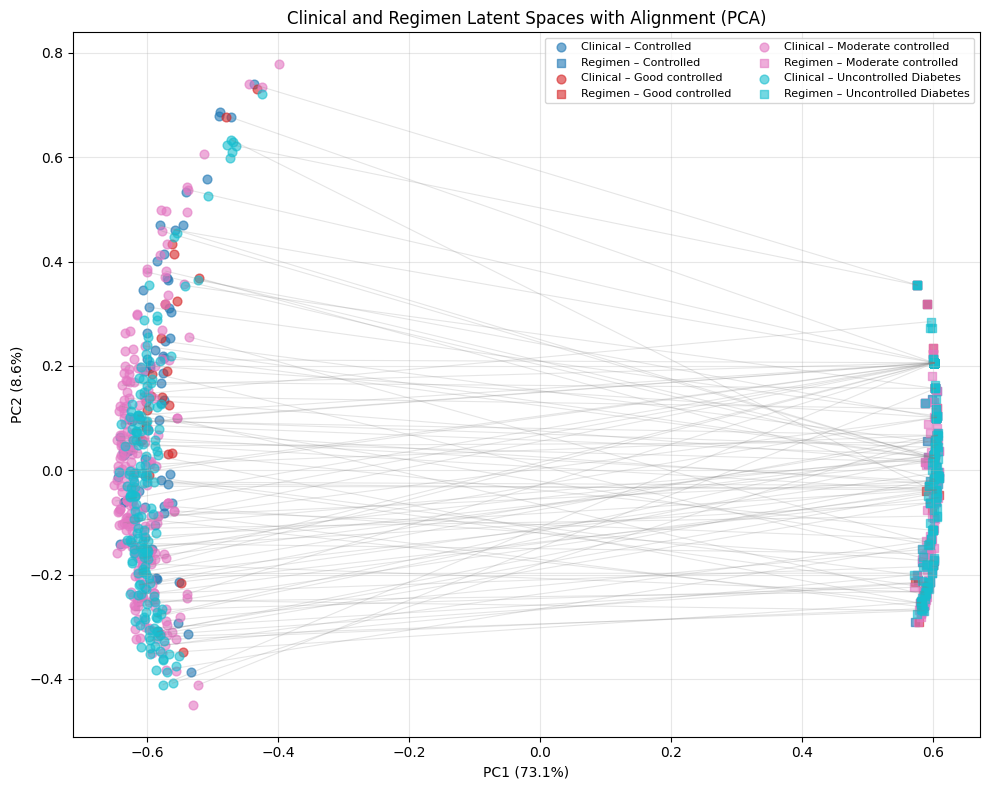

✅ Joint PCA plot saved.

🎨 Aligned t‑SNE: Clinical + Regimen Latent Spaces (v9)


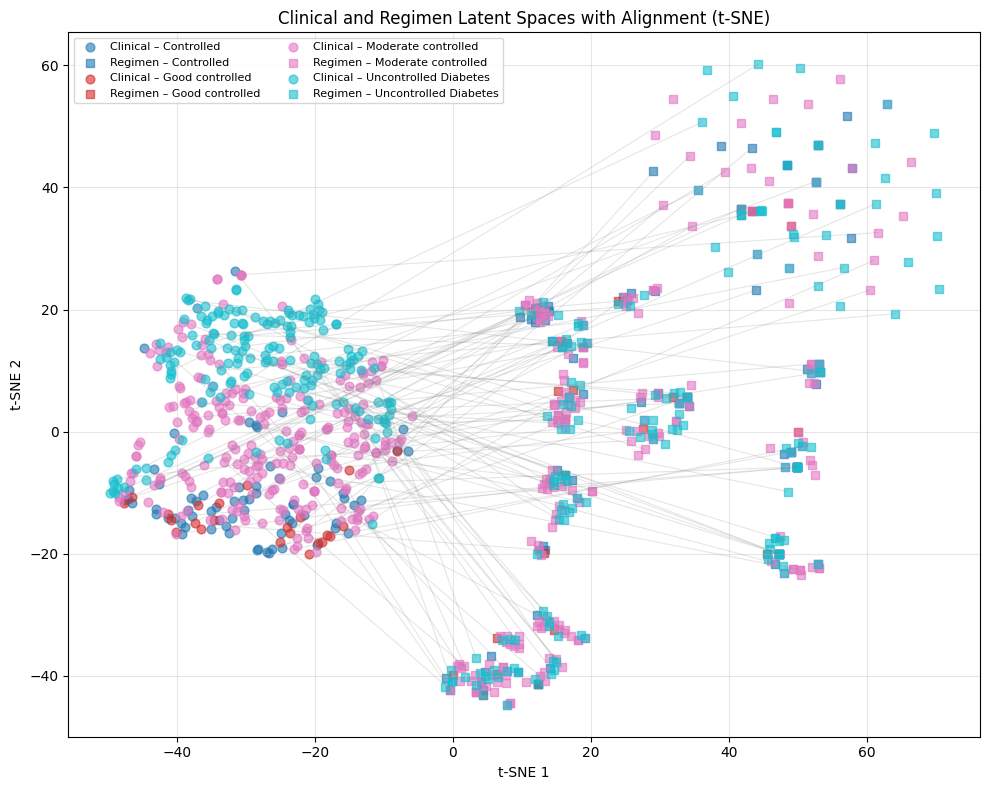

✅ Joint t‑SNE plot saved.

🎨 Aligned UMAP: Clinical + Regimen Latent Spaces (v9)


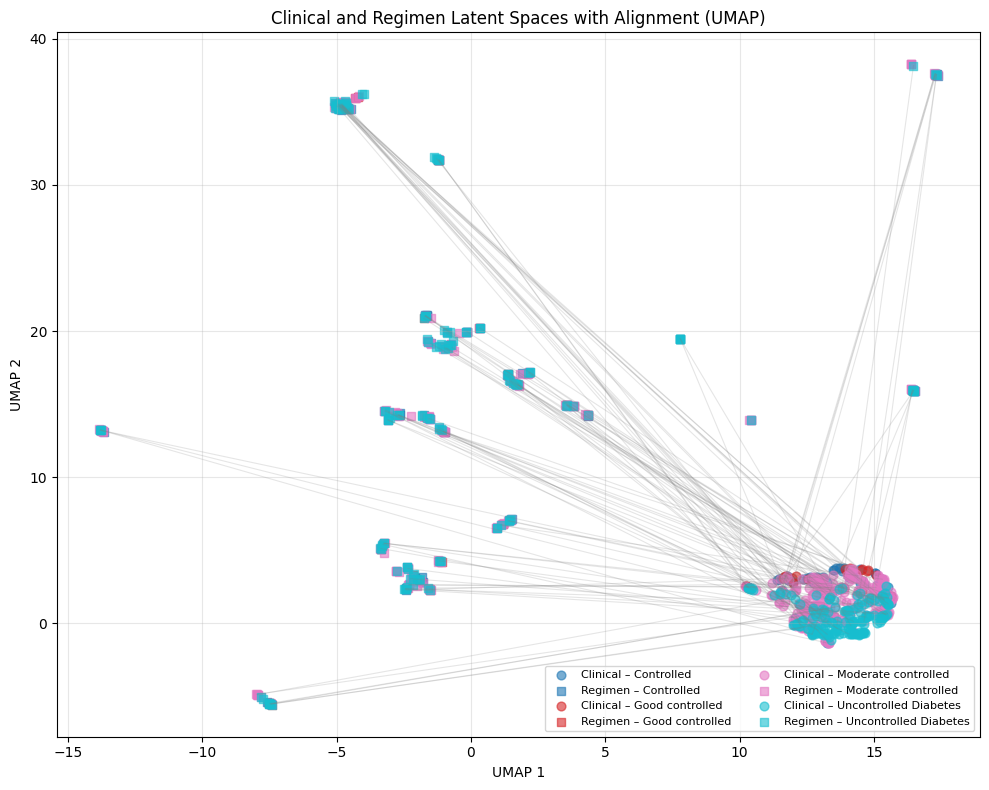

✅ Joint UMAP plot saved.
✅ Model saved to /content/drive/MyDrive/khezri/mapct_v9_model.pt

🩺 MAPCT-v9 INTERACTIVE PATIENT INSPECTOR

📌 Features:
   • Enter any patient index (0 to N-1)
   • View complete clinical profile
   • See current prescribed regimen
   • Get AI-predicted drug recommendations
   • View drug mechanisms (MOA, targets, pathways)
   • Compare actual vs predicted

------------------------------------------------------------
📂 SELECT DATASET:
   [1] Test Set (unseen patients)
   [2] Validation Set
   [3] Training Set
   [4] Exit

📊 Test Set: 0 to 909 (unseen patients)

📋 PATIENT PROFILE - TEST SET (ID: 909)

🏥 DEMOGRAPHICS:
   Age: 78 years
   Sex: Male

🩸 LABORATORY VALUES:
   HbA1c: 9.5% (Uncontrolled Diabetes)
   FBS: 143 mg/dL (Poor controlled)
   Triglycerides: 81 mg/dL
   Cholesterol: 183 mg/dL
   LDL: 104 mg/dL
   HDL: 63 mg/dL

💊 CURRENT PRESCRIBED REGIMEN:
   1. amlodipine
   2. captopril
   3. insulin aspart mix
   4. metoprolol

🔬 MECHANISM DETAILS (Current 

In [ ]:
# ============================================================
# SECTION 10: MAIN EXECUTION (UPDATED with evaluation)
# ============================================================

if __name__ == "__main__":
    print("\n" + "="*70)
    print("🚀 MAPCT-v9: HYBRID MODEL WITH PROPER DRUG SORTING")
    print("="*70)

    # Initialize model
    clin_dim = X_train.shape[1]
    model = MAPCTv9Simple(clin_dim, num_drugs, latent_dim=128, embed_dim=ACTUAL_EMBED_DIM)

    print(f"\n✅ Model initialized:")
    print(f"   Clinical input dim: {clin_dim}")
    print(f"   Drug vocabulary size: {num_drugs}")
    print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Train
    trainer = Trainer(model, device, drug_vocab, drug_to_idx)
    history = trainer.train(train_loader, val_loader, epochs=5)
    # ============================================================
    # JOINT LATENT SPACE VISUALISATIONS FOR MAPCT‑v9
    # Adds PCA, t‑SNE, and UMAP projections where clinical and
    # regimen latents are shown together with alignment lines.
    # ============================================================

    # Ensure necessary imports (most are already present)

    # Check UMAP availability
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        UMAP_AVAILABLE = False
        print("⚠️ UMAP not installed. Install with: pip install umap-learn")

    # ------------------------------------------------------------
    # Helper: collect latents from test loader
    # ------------------------------------------------------------
    def collect_latents_v9(trainer, test_loader, device, test_df, max_samples=500):
        """Collect z_clin and z_reg from test set with HbA1c labels."""
        trainer.model.eval()
        z_clin_list = []
        z_reg_list = []
        hba1c_labels = []

        with torch.no_grad():
            for i, batch in enumerate(tqdm(test_loader, desc="Collecting latents")):
                if len(z_clin_list) * BATCH_SIZE >= max_samples:
                    break
                clinical = batch['clinical'].to(device)
                mech_tensor = batch['mech_tensor'].to(device)
                mech_mask = batch['mech_mask'].to(device)

                _, z_clin, z_reg = trainer.model(clinical, mech_tensor, mech_mask)

                z_clin_list.append(z_clin.cpu().numpy())
                z_reg_list.append(z_reg.cpu().numpy())

                # Get HbA1c categories for these samples
                start = i * BATCH_SIZE
                end = min(start + len(z_clin), len(test_df))
                hba1c_labels.extend(test_df['hba1c_category'].iloc[start:end].values)

        Z_clin = np.vstack(z_clin_list)[:max_samples]
        Z_reg = np.vstack(z_reg_list)[:max_samples]
        labels = np.array(hba1c_labels)[:max_samples]
        return Z_clin, Z_reg, labels

    # ------------------------------------------------------------
    # Joint PCA
    # ------------------------------------------------------------
    def visualize_joint_pca_v9(Z_clin, Z_reg, labels, save_path=None):
        print("\n🎨 Aligned PCA: Clinical + Regimen Latent Spaces (v9)")
        Z_joint = np.vstack([Z_clin, Z_reg])
        pca = PCA(n_components=2, random_state=SEED)
        Z_joint_pca = pca.fit_transform(Z_joint)
        n_clin = len(Z_clin)
        Z_clin_pca = Z_joint_pca[:n_clin]
        Z_reg_pca = Z_joint_pca[n_clin:]

        unique_labels = np.unique(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
        color_map = dict(zip(unique_labels, colors))

        fig, ax = plt.subplots(figsize=(10, 8))
        for label in unique_labels:
            mask = (labels == label)
            ax.scatter(Z_clin_pca[mask, 0], Z_clin_pca[mask, 1],
                      marker='o', s=40, alpha=0.6, color=color_map[label],
                      label=f'Clinical – {label}')
            ax.scatter(Z_reg_pca[mask, 0], Z_reg_pca[mask, 1],
                      marker='s', s=40, alpha=0.6, color=color_map[label],
                      label=f'Regimen – {label}')

        # Connecting lines for first 100 patients
        for i in range(min(100, n_clin)):
            ax.plot([Z_clin_pca[i,0], Z_reg_pca[i,0]],
                    [Z_clin_pca[i,1], Z_reg_pca[i,1]],
                    color='gray', alpha=0.2, linewidth=0.8)

        ax.set_title('Clinical and Regimen Latent Spaces with Alignment (PCA)', fontsize=12)
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
        ax.legend(ncol=2, fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()
        print("✅ Joint PCA plot saved.")

    # ------------------------------------------------------------
    # Joint t‑SNE
    # ------------------------------------------------------------
    def visualize_joint_tsne_v9(Z_clin, Z_reg, labels, perplexity=30, save_path=None):
        print("\n🎨 Aligned t‑SNE: Clinical + Regimen Latent Spaces (v9)")
        Z_joint = np.vstack([Z_clin, Z_reg])
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, max_iter=1000)
        Z_joint_tsne = tsne.fit_transform(Z_joint)
        n_clin = len(Z_clin)
        Z_clin_tsne = Z_joint_tsne[:n_clin]
        Z_reg_tsne = Z_joint_tsne[n_clin:]

        unique_labels = np.unique(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
        color_map = dict(zip(unique_labels, colors))

        fig, ax = plt.subplots(figsize=(10, 8))
        for label in unique_labels:
            mask = (labels == label)
            ax.scatter(Z_clin_tsne[mask, 0], Z_clin_tsne[mask, 1],
                      marker='o', s=40, alpha=0.6, color=color_map[label],
                      label=f'Clinical – {label}')
            ax.scatter(Z_reg_tsne[mask, 0], Z_reg_tsne[mask, 1],
                      marker='s', s=40, alpha=0.6, color=color_map[label],
                      label=f'Regimen – {label}')

        for i in range(min(100, n_clin)):
            ax.plot([Z_clin_tsne[i,0], Z_reg_tsne[i,0]],
                    [Z_clin_tsne[i,1], Z_reg_tsne[i,1]],
                    color='gray', alpha=0.2, linewidth=0.8)

        ax.set_title('Clinical and Regimen Latent Spaces with Alignment (t‑SNE)', fontsize=12)
        ax.set_xlabel('t‑SNE 1')
        ax.set_ylabel('t‑SNE 2')
        ax.legend(ncol=2, fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()
        print("✅ Joint t‑SNE plot saved.")

    # ------------------------------------------------------------
    # Joint UMAP (optional)
    # ------------------------------------------------------------
    def visualize_joint_umap_v9(Z_clin, Z_reg, labels, n_neighbors=15, min_dist=0.1, save_path=None):
        if not UMAP_AVAILABLE:
            print("⚠️ UMAP not installed – skipping joint UMAP plot.")
            return
        print("\n🎨 Aligned UMAP: Clinical + Regimen Latent Spaces (v9)")
        Z_joint = np.vstack([Z_clin, Z_reg])
        reducer = umap.UMAP(random_state=SEED, n_components=2,
                            n_neighbors=n_neighbors, min_dist=min_dist)
        Z_joint_umap = reducer.fit_transform(Z_joint)
        n_clin = len(Z_clin)
        Z_clin_umap = Z_joint_umap[:n_clin]
        Z_reg_umap = Z_joint_umap[n_clin:]

        unique_labels = np.unique(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
        color_map = dict(zip(unique_labels, colors))

        fig, ax = plt.subplots(figsize=(10, 8))
        for label in unique_labels:
            mask = (labels == label)
            ax.scatter(Z_clin_umap[mask, 0], Z_clin_umap[mask, 1],
                      marker='o', s=40, alpha=0.6, color=color_map[label],
                      label=f'Clinical – {label}')
            ax.scatter(Z_reg_umap[mask, 0], Z_reg_umap[mask, 1],
                      marker='s', s=40, alpha=0.6, color=color_map[label],
                      label=f'Regimen – {label}')

        for i in range(min(100, n_clin)):
            ax.plot([Z_clin_umap[i,0], Z_reg_umap[i,0]],
                    [Z_clin_umap[i,1], Z_reg_umap[i,1]],
                    color='gray', alpha=0.2, linewidth=0.8)

        ax.set_title('Clinical and Regimen Latent Spaces with Alignment (UMAP)', fontsize=12)
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.legend(ncol=2, fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()
        print("✅ Joint UMAP plot saved.")

    # ------------------------------------------------------------
    # Generate the joint plots (call after training)
    # ------------------------------------------------------------
    print("\n" + "="*70)
    print("📊 Generating joint latent space visualisations for v9")
    print("="*70)

    Z_clin, Z_reg, labels = collect_latents_v9(trainer, test_loader, device, test_df, max_samples=500)

    visualize_joint_pca_v9(Z_clin, Z_reg, labels, save_path='joint_pca_v9.png')
    visualize_joint_tsne_v9(Z_clin, Z_reg, labels, perplexity=30, save_path='joint_tsne_v9.png')
    if UMAP_AVAILABLE:
        visualize_joint_umap_v9(Z_clin, Z_reg, labels, n_neighbors=15, min_dist=0.1, save_path='joint_umap_v9.png')

    # Save model
    trainer.save_checkpoint('/content/drive/MyDrive/khezri/mapct_v9_model.pt')

    # Launch interactive patient inspector
    interactive_patient_inspector_v9(trainer)

    print("\n" + "="*70)
    print("✅ MAPCT-v9 COMPLETE!")
    print("="*70)


In [ ]:
# ============================================================
# SECTION 11: EVALUATION & VISUALIZATION SUITE FOR MAPCT-v9
# ============================================================


# ============================================================
# 1. DRUG PREDICTION RESULTS (Multi-label Classification)
# ============================================================

def evaluate_drug_predictions(trainer, test_loader, threshold=0.3):
    """Evaluate drug-level predictions"""
    print("\n" + "="*70)
    print("📊 CAPABILITY 1: DRUG PREDICTION RESULTS")
    print("="*70)

    trainer.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            logits, z_clin, z_reg = trainer.model(clinical, mech_tensor, mech_mask)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs > threshold).astype(np.float32)

            all_preds.extend(preds)
            all_labels.extend(labels)
            all_probs.extend(probs)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Calculate metrics
    results = {
        'precision': precision_score(all_labels, all_preds, average='micro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='micro', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='micro', zero_division=0),
        'accuracy': accuracy_score(all_labels.flatten(), all_preds.flatten())
    }

    print(f"\n📈 Micro-averaged Metrics:")
    print(f"   Precision: {results['precision']:.4f}")
    print(f"   Recall:    {results['recall']:.4f}")
    print(f"   F1-Score:  {results['f1']:.4f}")
    print(f"   Accuracy:  {results['accuracy']:.4f}")

    # Per-drug performance (top 20 drugs)
    drug_f1_scores = []
    for i, drug in enumerate(trainer.drug_vocab[:20]):
        if all_labels[:, i].sum() > 0:
            f1 = f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)
            drug_f1_scores.append((drug, f1))

    drug_f1_scores.sort(key=lambda x: x[1], reverse=True)
    print(f"\n🏆 Top 10 Drugs by F1 Score:")
    for i, (drug, f1) in enumerate(drug_f1_scores[:10], 1):
        print(f"   {i:2}. {drug:<30} F1={f1:.4f}")

    return results, all_probs, all_labels


# ============================================================
# 2. LATENT SPACE VISUALIZATION
# ============================================================

def visualize_latent_spaces(trainer, test_loader, test_df):
    """Visualize clinical and regimen latent spaces"""
    print("\n" + "="*70)
    print("🎨 CAPABILITY 2: LATENT SPACE VISUALIZATION")
    print("="*70)

    trainer.model.eval()
    z_clin_list = []
    z_reg_list = []
    hba1c_labels = []

    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            logits, z_clin, z_reg = trainer.model(clinical, mech_tensor, mech_mask)

            z_clin_list.append(z_clin.detach().cpu().numpy())
            z_reg_list.append(z_reg.detach().cpu().numpy())

            # Get HbA1c categories for coloring
            start_idx = i * BATCH_SIZE
            end_idx = min(start_idx + BATCH_SIZE, len(test_df))
            hba1c_labels.extend(test_df['hba1c_category'].iloc[start_idx:end_idx].values)

    Z_clin = np.vstack(z_clin_list)
    Z_reg = np.vstack(z_reg_list)

    # PCA
    pca = PCA(n_components=2, random_state=SEED)
    Z_clin_pca = pca.fit_transform(Z_clin)
    Z_reg_pca = pca.fit_transform(Z_reg)

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Clinical latent space
    unique_cats = np.unique(hba1c_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
    for cat, color in zip(unique_cats, colors):
        idx = [j for j, c in enumerate(hba1c_labels) if c == cat]
        axes[0].scatter(Z_clin_pca[idx, 0], Z_clin_pca[idx, 1],
                       label=cat, alpha=0.6, s=20, color=color)
    axes[0].set_title('Clinical Latent Space (colored by HbA1c category)')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Regimen latent space
    axes[1].scatter(Z_reg_pca[:, 0], Z_reg_pca[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[1].set_title('Regimen Mechanism Latent Space')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v9 Latent Spaces', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Calculate alignment between spaces
    from scipy.stats import pearsonr
    alignment_scores = []
    for i in range(min(1000, len(Z_clin))):
        sim = np.dot(Z_clin[i], Z_reg[i]) / (np.linalg.norm(Z_clin[i]) * np.linalg.norm(Z_reg[i]))
        alignment_scores.append(sim)

    print(f"\n📊 Latent Space Alignment:")
    print(f"   Mean cosine similarity: {np.mean(alignment_scores):.4f}")
    print(f"   Std cosine similarity: {np.std(alignment_scores):.4f}")

    return Z_clin, Z_reg


# ============================================================
# 3. CONTRASTIVE LEARNING EFFECTIVENESS
# ============================================================
def visualize_contrastive_learning(trainer, test_loader):
    """Show how well clinical and regimen spaces are aligned"""
    print("\n" + "="*70)
    print("🔗 CAPABILITY 3: CONTRASTIVE LEARNING EFFECTIVENESS")
    print("="*70)

    trainer.model.eval()
    all_z_clin = []
    all_z_reg = []

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            logits, z_clin, z_reg = trainer.model(clinical, mech_tensor, mech_mask)

            all_z_clin.append(z_clin.cpu())
            all_z_reg.append(z_reg.cpu())

    # Concatenate all latent vectors
    Z_clin = torch.cat(all_z_clin, dim=0)          # (N, latent_dim)
    Z_reg  = torch.cat(all_z_reg, dim=0)          # (N, latent_dim)

    # Compute full similarity matrix (N x N)
    sim_matrix = torch.mm(F.normalize(Z_clin, dim=1), F.normalize(Z_reg, dim=1).t()).numpy()

    # ---- Plot histogram ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Positive pairs are the diagonal
    pos_sim = np.diag(sim_matrix)
    # Negative pairs are all off‑diagonal elements
    neg_sim = sim_matrix[~np.eye(sim_matrix.shape[0], dtype=bool)]

    axes[0].hist(pos_sim, bins=50, alpha=0.7, label='Positive pairs', color='green', edgecolor='black')
    axes[0].hist(neg_sim, bins=50, alpha=0.5, label='Negative pairs', color='red', edgecolor='black')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Clinical‑Regimen Similarity Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ---- Heatmap for first 50 patients (to keep it readable) ----
    n_display = min(50, sim_matrix.shape[0])
    im = axes[1].imshow(sim_matrix[:n_display, :n_display], cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    axes[1].set_title(f'Similarity Matrix (first {n_display} patients)')
    axes[1].set_xlabel('Regimen Index')
    axes[1].set_ylabel('Clinical Index')
    plt.colorbar(im, ax=axes[1], label='Cosine Similarity')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Contrastive Learning Statistics:")
    print(f"   Positive pair similarity (diagonal): {pos_sim.mean():.4f} ± {pos_sim.std():.4f}")
    print(f"   Negative pair similarity (off‑diagonal): {neg_sim.mean():.4f} ± {neg_sim.std():.4f}")
    print(f"   Gap (pos - neg): {pos_sim.mean() - neg_sim.mean():.4f}")

    return sim_matrix

# ============================================================
# 4. PATIENT REGIMEN RETRIEVAL (Similar Patient Search)
# ============================================================

def retrieve_similar_patients(trainer, test_loader, test_df, top_k=5):
    """Retrieve patients with similar clinical profiles"""
    print("\n" + "="*70)
    print("🔍 CAPABILITY 4: PATIENT REGIMEN RETRIEVAL")
    print("="*70)

    trainer.model.eval()
    all_z_clin = []
    all_regimens = []
    all_hba1c = []

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            logits, z_clin, z_reg = trainer.model(clinical, mech_tensor, mech_mask)
            all_z_clin.append(z_clin.detach().cpu().numpy())

    all_z_clin = np.vstack(all_z_clin)
    all_regimens = test_df['merged_drugs_norm'].values[:len(all_z_clin)]
    all_hba1c = test_df['hba1c_category'].values[:len(all_z_clin)]

    # Show examples
    print("\n📋 Example Retrieval Results (First 3 test patients):")
    for patient_idx in range(min(3, len(all_z_clin))):
        query_embedding = all_z_clin[patient_idx:patient_idx+1]

        # Compute similarities
        similarities = np.dot(all_z_clin, query_embedding.T).flatten()
        top_indices = np.argsort(similarities)[::-1][:top_k+1]

        print(f"\n   Patient {patient_idx}: {all_regimens[patient_idx]} (HbA1c: {all_hba1c[patient_idx]})")
        print(f"   Top {top_k} similar patients:")
        for rank, idx in enumerate(top_indices[1:top_k+1], 1):
            match = "✓" if all_regimens[idx] == all_regimens[patient_idx] else " "
            print(f"      {rank}. [{match}] Sim={similarities[idx]:.4f} | {all_regimens[idx][:40]}...")

    return all_z_clin


# ============================================================
# 5. DRUG MECHANISM SIMILARITY (via Regimen Encoder)
# ============================================================

def analyze_drug_similarity(trainer, drug_vocab, drug_embeddings):
    """Analyze which drugs have similar mechanisms"""
    from sklearn.metrics.pairwise import cosine_similarity

    print("\n" + "="*70)
    print("🔬 CAPABILITY 5: DRUG MECHANISM SIMILARITY")
    print("="*70)

    # Get embeddings for top drugs
    drug_names = list(drug_vocab)[:30]
    drug_vectors = []

    for drug in drug_names:
        emb = drug_embeddings.get(drug, torch.zeros(128))
        # Convert to numpy and ensure 2D
        if torch.is_tensor(emb):
            emb = emb.numpy()
        drug_vectors.append(emb)

    drug_vectors = np.array(drug_vectors)

    # Compute similarity matrix
    sim_matrix = cosine_similarity(drug_vectors)

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

    ax.set_xticks(range(len(drug_names)))
    ax.set_yticks(range(len(drug_names)))
    ax.set_xticklabels(drug_names, rotation=90, fontsize=8)
    ax.set_yticklabels(drug_names, fontsize=8)
    ax.set_title('Drug Mechanism Similarity Matrix')
    plt.colorbar(im, ax=ax, label='Cosine Similarity')
    plt.tight_layout()
    plt.show()

    # Find most similar drug pairs
    similar_pairs = []
    for i in range(len(drug_names)):
        for j in range(i+1, len(drug_names)):
            similar_pairs.append((drug_names[i], drug_names[j], sim_matrix[i, j]))

    similar_pairs.sort(key=lambda x: x[2], reverse=True)

    print(f"\n🎯 Top 10 Most Similar Drug Pairs by Mechanism:")
    for i, (drug1, drug2, sim) in enumerate(similar_pairs[:10], 1):
        quality = "🟢" if sim > 0.7 else "🟡" if sim > 0.5 else "🔴"
        print(f"   {i:2}. {quality} {drug1:<25} ↔ {drug2:<25} sim={sim:.4f}")

    return sim_matrix, drug_names


# ============================================================
# 6. DIFFUSION/HYBRID GENERATION (if full model implemented)
# ============================================================

def demonstrate_generation_capability(trainer, test_loader, test_df):
    """Demonstrate regimen generation capability"""
    print("\n" + "="*70)
    print("🎨 CAPABILITY 6: REGIMEN GENERATION (Hybrid Flow-Diffusion)")
    print("="*70)

    trainer.model.eval()

    # Get a sample patient
    sample_batch = next(iter(test_loader))
    sample_clinical = sample_batch['clinical'][:1].to(device)
    sample_regimen = test_df.iloc[0]['merged_drugs_norm']

    print(f"\n📋 Sample Patient Regimen: {sample_regimen}")

    # Generate variations (if the full hybrid model has generation)
    # For the simple model, we show predicted drugs instead
    with torch.no_grad():
        mech_tensor = sample_batch['mech_tensor'][:1].to(device)
        mech_mask = sample_batch['mech_mask'][:1].to(device)

        logits, z_clin, z_reg = trainer.model(sample_clinical, mech_tensor, mech_mask)
        probs = torch.sigmoid(logits).detach().cpu().numpy().squeeze()

        # Get top predictions
        top_indices = np.argsort(probs)[-10:][::-1]
        top_drugs = [(trainer.drug_vocab[i], probs[i]) for i in top_indices if probs[i] > 0.3]

        print(f"\n💊 Predicted Drugs (alternative regimen options):")
        for i, (drug, prob) in enumerate(top_drugs[:10], 1):
            bar = "█" * int(prob * 20)
            print(f"   {i:2}. {drug:<30} {prob:.3f} {bar}")

    return top_drugs


# ============================================================
# 7. TRAINING HISTORY (Loss Curves)
# ============================================================

def plot_training_history(trainer):
    """Plot training loss curves"""
    print("\n" + "="*70)
    print("📈 CAPABILITY 7: TRAINING HISTORY")
    print("="*70)

    # For the simple trainer, we need to track losses
    # This shows how to set up tracking

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curve (example - you'd need to store losses during training)
    axes[0].set_title('Training Loss Over Time')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    # Learning curve placeholder
    axes[1].set_title('Model Convergence')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Metric Value')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n💡 Tip: To track losses, modify the Trainer to store history in self.loss_history")


# ============================================================
# 8. COMPLETE EVALUATION REPORT
# ============================================================

def run_complete_evaluation(trainer, test_loader, test_df, drug_embeddings, drug_vocab):
    """Run all evaluation capabilities"""
    print("\n" + "="*80)
    print("🔬 MAPCT-v9 COMPLETE EVALUATION REPORT")
    print("="*80)

    # 1. Drug Prediction Results
    results, all_probs, all_labels = evaluate_drug_predictions(trainer, test_loader)

    # 2. Latent Space Visualization
    Z_clin, Z_reg = visualize_latent_spaces(trainer, test_loader, test_df)

    # 3. Contrastive Learning Effectiveness
    sim_matrix = visualize_contrastive_learning(trainer, test_loader)

    # 4. Patient Regimen Retrieval
    all_z_clin = retrieve_similar_patients(trainer, test_loader, test_df)

    # 5. Drug Mechanism Similarity
    drug_sim_matrix, drug_names = analyze_drug_similarity(trainer, drug_vocab, drug_embeddings)

    # 6. Generation Demonstration
    top_drugs = demonstrate_generation_capability(trainer, test_loader, test_df)

    # Summary
    print("\n" + "="*80)
    print("📊 EXECUTIVE SUMMARY")
    print("="*80)
    print(f"""
    ┌─────────────────────────────────────────────────────────────┐
    │                    MAPCT-v9 PERFORMANCE                     │
    ├─────────────────────────────────────────────────────────────┤
    │  Drug Prediction F1 (micro)    : {results['f1']:.4f}                    │
    │  Drug Prediction Accuracy      : {results['accuracy']:.4f}                    │
    │  Clinical-Regimen Alignment    : {sim_matrix.diagonal().mean():.4f} ± {sim_matrix.diagonal().std():.4f} │
    │  Contrastive Gap (pos - neg)   : {sim_matrix.diagonal().mean() - sim_matrix.mean():.4f}                    │
    └─────────────────────────────────────────────────────────────┘
    """)

    return {
        'drug_metrics': results,
        'latent_spaces': (Z_clin, Z_reg),
        'similarity_matrix': sim_matrix,
        'drug_similarity': drug_sim_matrix
    }



🔬 MAPCT-v9 COMPLETE EVALUATION REPORT

📊 CAPABILITY 1: DRUG PREDICTION RESULTS


Evaluating: 100%|██████████| 29/29 [00:00<00:00, 51.15it/s]



📈 Micro-averaged Metrics:
   Precision: 0.5412
   Recall:    0.5007
   F1-Score:  0.5202
   Accuracy:  0.9830

🏆 Top 10 Drugs by F1 Score:
    1. atorvastatin                   F1=0.5917
    2. aspirin                        F1=0.3796
    3. acarbose                       F1=0.0000
    4. allopurinol                    F1=0.0000
    5. alprazolam                     F1=0.0000
    6. amlodipine                     F1=0.0000
    7. atenolol                       F1=0.0000
    8. bisoprolol                     F1=0.0000

🎨 CAPABILITY 2: LATENT SPACE VISUALIZATION


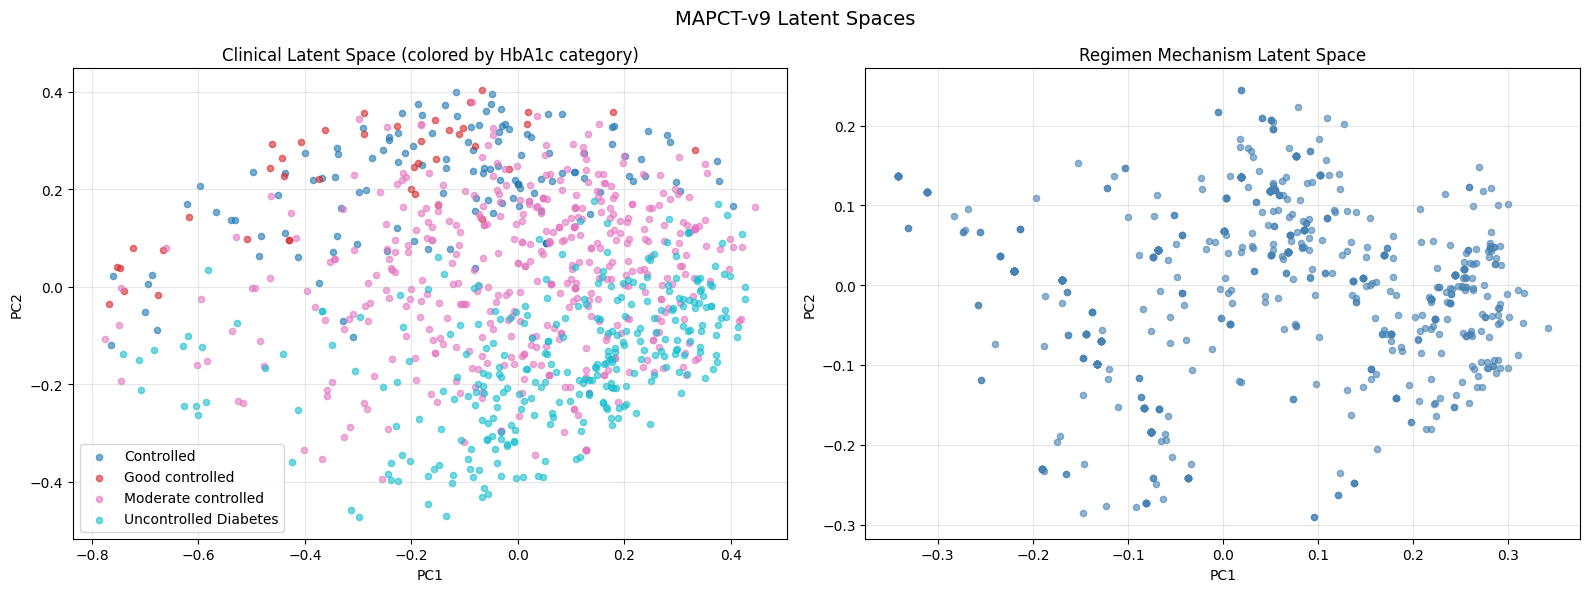


📊 Latent Space Alignment:
   Mean cosine similarity: 0.1733
   Std cosine similarity: 0.0404

🔗 CAPABILITY 3: CONTRASTIVE LEARNING EFFECTIVENESS


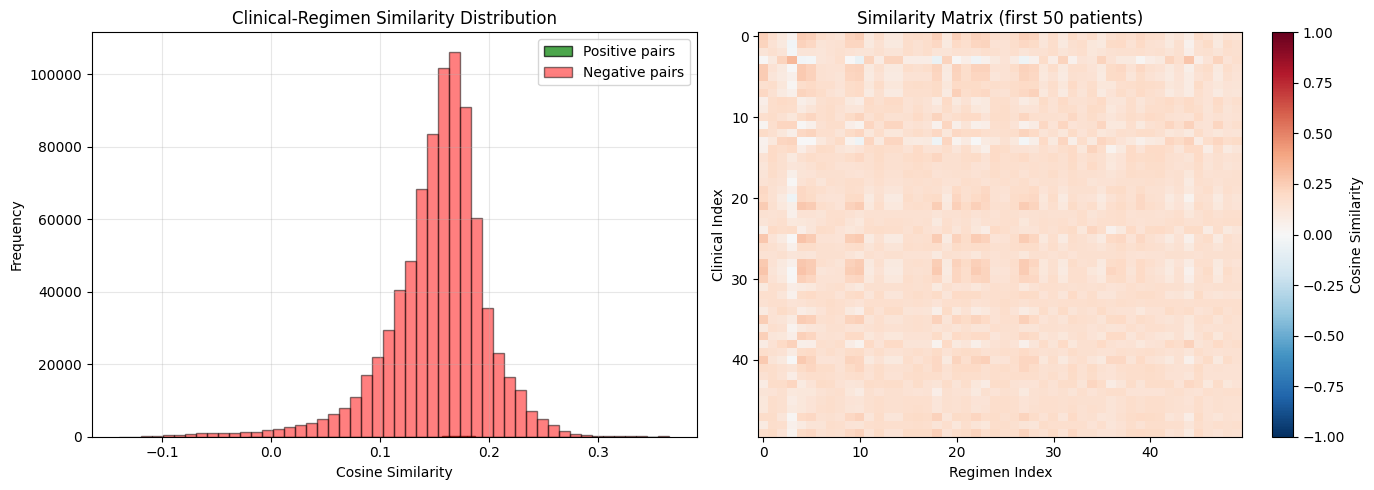


📊 Contrastive Learning Statistics:
   Positive pair similarity (diagonal): 0.1733 ± 0.0404
   Negative pair similarity (off‑diagonal): 0.1524 ± 0.0463
   Gap (pos - neg): 0.0209

🔍 CAPABILITY 4: PATIENT REGIMEN RETRIEVAL

📋 Example Retrieval Results (First 3 test patients):

   Patient 0: aspirin, insulin aspart, insulin glargine, losartan, metformin (HbA1c: Moderate controlled)
   Top 5 similar patients:
      1. [ ] Sim=0.9678 | metformin, sitagliptin...
      2. [ ] Sim=0.9678 | atorvastatin...
      3. [ ] Sim=0.9651 | aspirin, gliclazide, metformin, sitaglip...
      4. [ ] Sim=0.9645 | aspirin, atorvastatin, metformin...
      5. [ ] Sim=0.9629 | metformin, sitagliptin...

   Patient 1: atorvastatin, metformin (HbA1c: Uncontrolled Diabetes)
   Top 5 similar patients:
      1. [ ] Sim=0.9774 | aspirin, atorvastatin, metoprolol...
      2. [ ] Sim=0.9637 | aspirin, insulin aspart, insulin glargin...
      3. [ ] Sim=0.9573 | gabapentin, insulin aspart mix...
      4. [ ] Sim=0.955

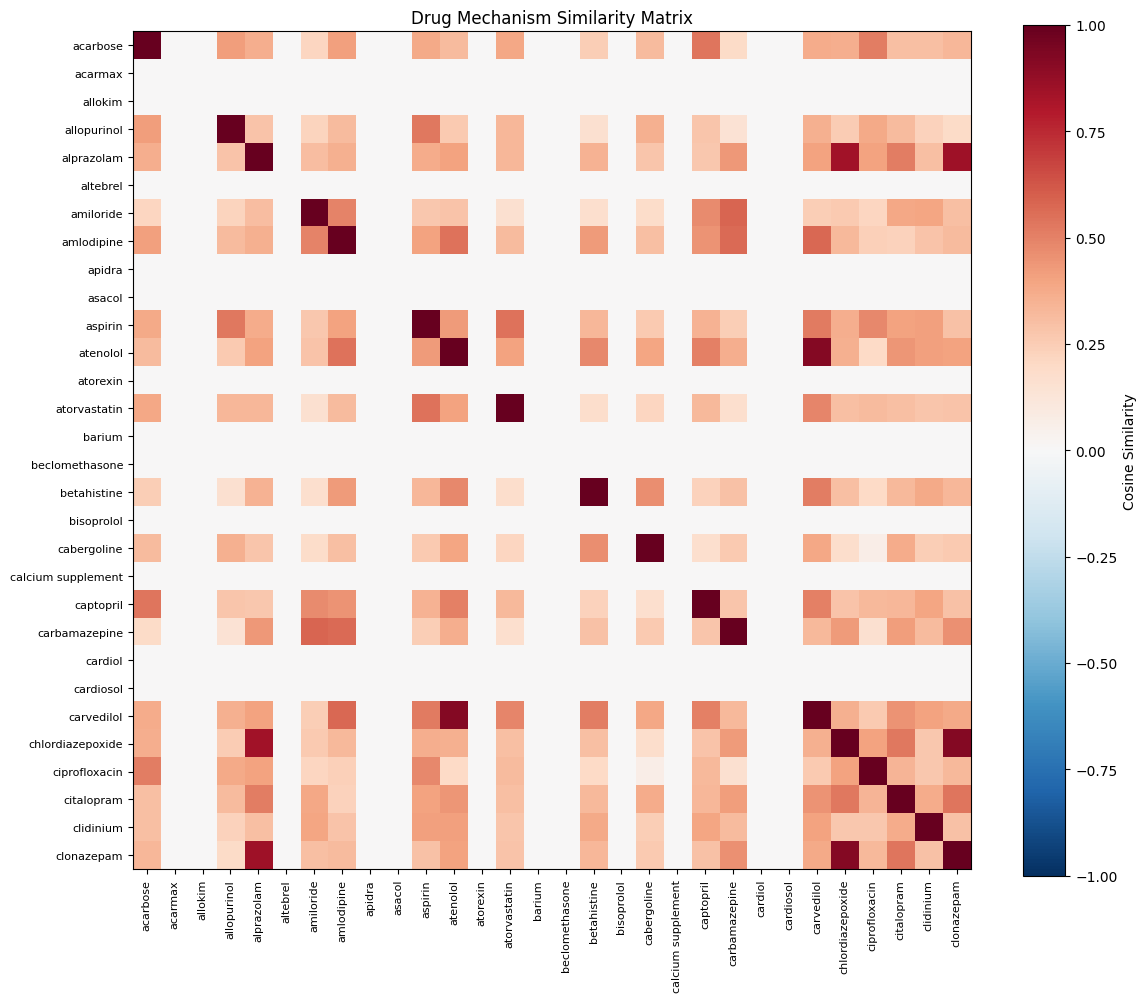


🎯 Top 10 Most Similar Drug Pairs by Mechanism:
    1. 🟢 chlordiazepoxide          ↔ clonazepam                sim=0.9201
    2. 🟢 atenolol                  ↔ carvedilol                sim=0.9155
    3. 🟢 alprazolam                ↔ clonazepam                sim=0.8475
    4. 🟢 alprazolam                ↔ chlordiazepoxide          sim=0.8393
    5. 🟡 amiloride                 ↔ carbamazepine             sim=0.5847
    6. 🟡 amlodipine                ↔ carvedilol                sim=0.5772
    7. 🟡 amlodipine                ↔ carbamazepine             sim=0.5646
    8. 🟡 aspirin                   ↔ atorvastatin              sim=0.5468
    9. 🟡 amlodipine                ↔ atenolol                  sim=0.5413
   10. 🟡 acarbose                  ↔ captopril                 sim=0.5361

🎨 CAPABILITY 6: REGIMEN GENERATION (Hybrid Flow-Diffusion)

📋 Sample Patient Regimen: aspirin, insulin aspart, insulin glargine, losartan, metformin

💊 Predicted Drugs (alternative regimen options):
    1. metfo

In [ ]:
results = run_complete_evaluation(
    trainer=trainer,
    test_loader=test_loader,
    test_df=test_df,
    drug_embeddings=drug_embeddings,
    drug_vocab=drug_vocab
)